---
## About Dataset

---

## 1. <font color='red'>Loading The Dataset</font>

---

In [156]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
# Importing Dependencies
import pandas as pd
import numpy as np
import re, os
import matplotlib.pyplot as plt
import torch
import cv2
import glob
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from google.colab.patches import cv2_imshow
from skimage import morphology
from torch.utils.data import DataLoader, random_split
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import confusion_matrix
from collections import Counter
import torchvision
from torchvision import datasets, transforms

In [158]:
train_dataset = datasets.MNIST(root="mnist",
                              train = True,
                              transform = transforms.ToTensor(), #<--- transform the train image to a 28 x 28 matrix
                              download = True)

test_dataset = datasets.MNIST(root = "mnist",
                             train = False,
                             transform = transforms.ToTensor()) #<--- Transform the test image to a 28x28 matrix

print(f"Train Dataset: {len(train_dataset):,}")
print(f"Test Dataset: {len(test_dataset):,}")

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 37.8MB/s]


Extracting mnist/MNIST/raw/train-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.25MB/s]


Extracting mnist/MNIST/raw/train-labels-idx1-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]


Extracting mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.87MB/s]

Extracting mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist/MNIST/raw

Train Dataset: 60,000
Test Dataset: 10,000


The MNIST data is separated in to Train (60,000) and Test (10,000). As a way of ensuring the model works well on different samples we will split the training data further into train and validation set.

---
### Creating The Validation Set

In [159]:
train_dataset, val_dataset = random_split(dataset = train_dataset, lengths = [55000, 5000])  #<--- Split data into Train & Val

Here we splitted data into 55,000 and 5000 for train and validation set respectively.

---

In [160]:
torch.manual_seed(42) # setting a seed for reproducbility.

train_loader = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)  #< -- Creating Train Dataloader
val_loader = DataLoader(dataset = val_dataset, batch_size = 64, shuffle = True)  #< -- Creating Val Dataloader
test_loader = DataLoader(dataset = test_dataset, batch_size = 64, shuffle = True)  #< -- Creating Test Dataloader

Create DataLoaders to efficiently iterate over the datasets during training and evaluation.

- Train_loader: Loads training data in batches of 64 and shuffles the data before each epoch.

- Val_loader: Loads validation data in batches of 64 and shuffles the data.

- Test_loader: Loads test data in batches of 64.

---
### Check Label Distribution

It's important to ensure that the dataset's label distribution is balanced, especially in training, validation, and test subsets. A skewed distribution can lead to a model that's biased towards the over-represented class. By examining label distribution, we can gain insights into the dataset's composition and make informed decisions about potential resampling or stratification strategies.

In [161]:
train_counter = Counter()
for images, labels in train_loader:
    train_counter.update(labels.tolist())

print("\nTraining label distribution:")
print(sorted(train_counter.items()))

val_counter = Counter()
for images, labels in val_loader:
    val_counter.update(labels.tolist())

print("\nValidation label distribution:")
print(sorted(val_counter.items()))

test_counter = Counter()
for images, labels in test_loader:
    test_counter.update(labels.tolist())

print("\Test label distribution:")
print(sorted(test_counter.items()))


Training label distribution:
[(0, 5426), (1, 6200), (2, 5467), (3, 5589), (4, 5360), (5, 4970), (6, 5390), (7, 5752), (8, 5387), (9, 5459)]

Validation label distribution:
[(0, 497), (1, 542), (2, 491), (3, 542), (4, 482), (5, 451), (6, 528), (7, 513), (8, 464), (9, 490)]
\Test label distribution:
[(0, 980), (1, 1135), (2, 1032), (3, 1010), (4, 982), (5, 892), (6, 958), (7, 1028), (8, 974), (9, 1009)]


---

>- The Training dataset has a relatively balanced distribution of each label, with a slight variation in counts.
>- The Validation dataset has a minor variation among different labels, but it's also fairly balanced.
>- The Test dataset's distribution is also balanced, following the trend of the other subsets.

Given that the distribution of the classes are close, we will be leaving them as they are

---

## 2. <font color='red'> Visualizing the data </font>

---

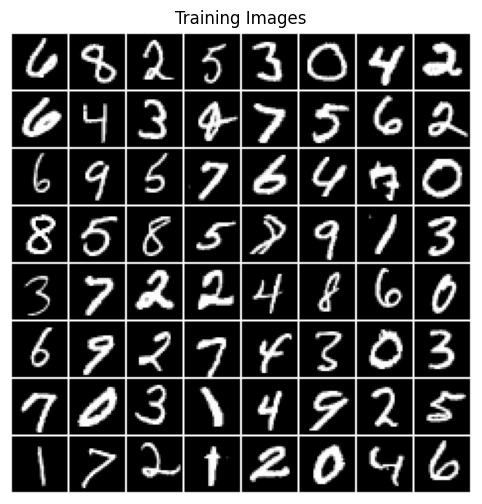

In [162]:
for images, labels in train_loader:
    break

plt.figure(figsize =(8,6))
plt.axis('off')
plt.title('Training Images')
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64], # 64 to visualize only the first batch selected in the iteration
    padding = 1,
    pad_value = 1.0,
    normalize = True),
    (1,2,0)))

plt.show()

To visualize what the data looks like, the above cell visualizes the first batch of hand written samples in the training set.

---

## 3. <font color='red'> Model </font>

---

In [163]:
# class NumbersClassifier(nn.Module):
#     def __init__(self, num_features, num_classes):
#         super().__init__()

#         self.all_layers = nn.Sequential(

#             # 1st hidden layer
#             nn.Linear(num_features, 50),
#             nn.ReLU(),

#             # 2nd hidden layer
#             nn.Linear(50,25),
#             nn.ReLU(),

#             # output Layer
#             nn.Linear(25, num_classes))

#     def forward(self, x):
#         x = torch.flatten(x, start_dim = 1)
#         logits = self.all_layers(x)
#         return logits

In [164]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # First Convolutional Layer
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)  # 1 input channel (grayscale image), 32 output channels (filters)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)  # Second convolution layer

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)  # MaxPooling with 2x2 window

        # Fully Connected (FC) Layer
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Flattened layer (assuming input images are 28x28, after pooling will be 7x7)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes for digit recognition (0-9)

    def forward(self, x):
        # Applying the first convolutional layer and activation
        x = self.pool(F.relu(self.conv1(x)))

        # Applying the second convolutional layer and activation
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the image for fully connected layer
        x = x.view(-1, 64 * 7 * 7)

        # Fully connected layers with ReLU activation
        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

# Instantiate the model
model = CNN()

# Print model summary
print(model)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


---
### **The Model**

The Convolution Neural Network above has been designed to identify patterns from input data (written digits) and classify them into 10 classes (0-9) by passing the data as neurons through 5 layers.

- Convolutional Layers:

The first 2 layers are the convolutional layers. These layers slide kernels through the images to identify patterns and extract features from the input images. The conv1 takes in the image as greayscale (1 color channel) and outputs a feature map of 32.


- Pooling Layer (pool):

This layer reduces the spatial dimensions of the feature maps, making the model more robust to variations in the input images.

- Fully Connected Layers (fc1, fc2):

These layers connect all the features extracted by the previous layers and perform the final classification. The last fully connected layer (fc2) has 10 output units, one for each digit (0-9).

---

## 4. <font color='red'> Training Loop </font>

---

In [165]:
# Creating a helper function
def compute_accuracy(model, dataloader):

    correct = 0
    total_examples = 0

    model = model.eval()

    for batch_idx, (features, labels) in enumerate(dataloader):

        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim = 1)

        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    accuracy_score = correct / total_examples

    return accuracy_score

In [166]:
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
total_step = len(train_loader)
epochs = 10

best_val_acc = 0.0  # Initialize best validation accuracy
epochs_without_improvement = 0  # Track epochs without validation accuracy improvement
patience = 3  # Number of epochs to wait before early stopping
model_save_path = '/content/drive/MyDrive/Module projects/ML&_Computer_Vision/best_model.pth'

train_loss_values = []
validation_loss_values = []
train_accuracy_values = []
validation_accuracy_values = []

for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()  # Clear previous gradients

        # Forward pass
        outputs = model(images)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()  # Compute gradients

        # Update weights
        optimizer.step()  # Update the model weights using the gradients

        # Track the loss
        running_loss += loss.item()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, epochs, i+1, total_step, loss.item()))

    # Train Loss
    epoch_train_loss = running_loss / len(train_loader)
    train_loss_values.append(epoch_train_loss)

    # Train Accuracy
    train_acc = compute_accuracy(model, train_loader)
    train_accuracy_values.append(train_acc)

    # Validation phase
    model.eval()
    with torch.no_grad():
        running_val_loss = 0.0
        correct = 0
        total = 0
        for images, labels in val_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        print('Epoch [{}/{}], Validation Accuracy: {:.4f}'.format(
            epoch + 1, epochs, val_acc))

        val_loss = running_val_loss / len(val_loader)  # Calculate average validation loss
        validation_loss_values.append(val_loss)
        validation_accuracy_values.append(val_acc)

        # Save the model if it has the best validation accuracy so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print('Saving best model...')
            torch.save(model.state_dict(), model_save_path)
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping triggered!")
                break  # Exit the training loop

Epoch [1/10], Step [100/860], Loss: 0.2255
Epoch [1/10], Step [200/860], Loss: 0.3078
Epoch [1/10], Step [300/860], Loss: 0.0329
Epoch [1/10], Step [400/860], Loss: 0.0413
Epoch [1/10], Step [500/860], Loss: 0.1013
Epoch [1/10], Step [600/860], Loss: 0.0780
Epoch [1/10], Step [700/860], Loss: 0.2488
Epoch [1/10], Step [800/860], Loss: 0.1856
Epoch [1/10], Validation Accuracy: 0.9824
Saving best model...
Epoch [2/10], Step [100/860], Loss: 0.0642
Epoch [2/10], Step [200/860], Loss: 0.0088
Epoch [2/10], Step [300/860], Loss: 0.0837
Epoch [2/10], Step [400/860], Loss: 0.0917
Epoch [2/10], Step [500/860], Loss: 0.0297
Epoch [2/10], Step [600/860], Loss: 0.0299
Epoch [2/10], Step [700/860], Loss: 0.0322
Epoch [2/10], Step [800/860], Loss: 0.0829
Epoch [2/10], Validation Accuracy: 0.9872
Saving best model...
Epoch [3/10], Step [100/860], Loss: 0.0530
Epoch [3/10], Step [200/860], Loss: 0.0382
Epoch [3/10], Step [300/860], Loss: 0.0061
Epoch [3/10], Step [400/860], Loss: 0.0524
Epoch [3/10], 

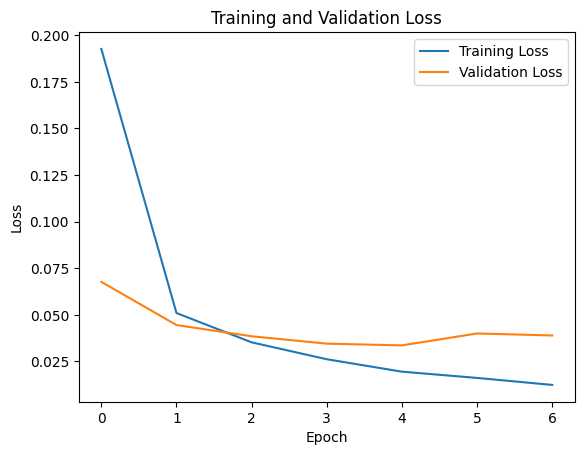

In [167]:
plt.plot(train_loss_values, label='Training Loss')
plt.plot(validation_loss_values, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

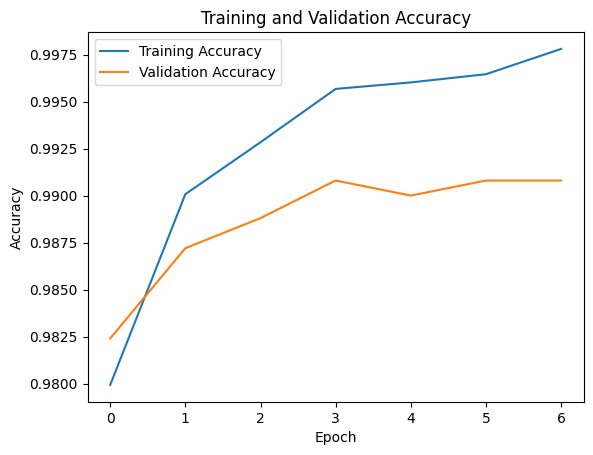

In [168]:
plt.plot(train_accuracy_values, label='Training Accuracy')
plt.plot(validation_accuracy_values, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

With the CNN defined we now create a training loop to iterate through the training data and pass them through the network.

- Loss Function:

  First we define the criterion which is the loss function (CrosSEnthropyLoss), it is well know to work well with multiclass classification problems. It tells us how well the model is predicting the classes and can indicate how to adjust the model.

- Optimizer:

  To adjust the models weights and biases as we try to minimize or reduce the loss we adopt the optim.Adam optimization algorithm which uses the fraient descent to update the moel's params. The learning rate being the steps taken to update the parameters.

- Epochs:

  This is the number of times we iterate through the data set for the model to learn patterns from the images in each batch.


In each epoch, we pass each batch of images to the model, compute the loss from the prediction, calculate the gradients for the weight and bias (backpropagation) and then update the model's parameters using the newly calculated weight and bias.

After each epoch the model's performance is evaluated on the validation set. If it exceeds its previous performance, we save the model and move to the next epoch. If the model fails to improve after 3 epochs, an early stopping is triggered to save the model from overfitting.

* Training and Validation Loss and Accuracy: The training and validation accuracy plots shows a very minimal difference in the models training performance and its performance on the validation set. It also achieved a constant drop in the trianing loss. Although the validation loss rose slightly it was still close to the training loss. This indicates that the model is generalizing well.

---

## 5. <font color='red'> Evaluating The Results </font>

---

In [169]:
model = CNN()
model_save_path = '/content/drive/MyDrive/Module projects/ML&_Computer_Vision/best_model.pth'
model.load_state_dict(torch.load(model_save_path))

<ipython-input-169-8db36e57cf32>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


<All keys matched successfully>

In [170]:
train_acc = compute_accuracy(model, train_loader)
val_acc = compute_accuracy(model, val_loader)
test_acc = compute_accuracy(model, test_loader)


print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Val Accuracy: {val_acc*100:>9.2f}%")
print(f"Test Accuracy: {test_acc*100:>7.2f}%")

Train Accuracy: 99.57%
Val Accuracy:     99.08%
Test Accuracy:   99.03%


With a Trainig accuracy of 99.93, Validation accuracy of 99.36 and Test Accuracy of 99.19, the model is perfroming very well. Although the Test accuracy is still slightly below the training accuracy.

In [ ]:
all_predictions = []
all_labels = []

with torch.no_grad():
  for images, labels in test_loader:
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)
      all_predictions.extend(predicted.numpy())  # Move to CPU if using GPU
      all_labels.extend(labels.numpy())  # Move to CPU if using GPU

cm = confusion_matrix(all_labels, all_predictions)


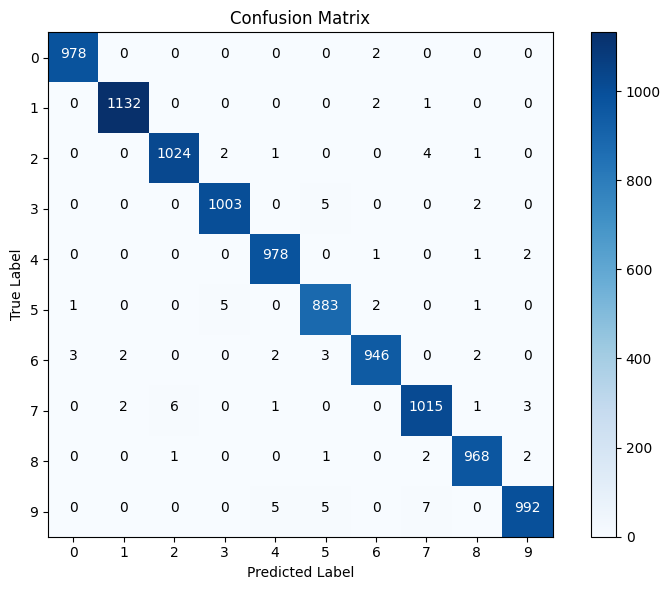

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations (counts) to the cells
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

The confusion matrix as seen above shows the models high perfromance in classifying the digits as seen on the diagonal with deeper blue shades. There are still some little errors. For example the class 9 was misclassified 17 times 5 times as 4, 5 times as 5 and 7 times as 7.

Overall the model shows high generalizaion.

#### Save trainined model

In [ ]:
# model_save_path = '/content/drive/MyDrive/Module projects/ML&_Computer_Vision/num_recg_model.pth'  # Choose your desired path
# torch.save(model.state_dict(), model_save_path)

In [44]:
model = CNN()
model_save_path = '/content/drive/MyDrive/Module projects/ML&_Computer_Vision/best_model.pth'
model.load_state_dict(torch.load(model_save_path))
model.eval()

<ipython-input-44-1f38474c5e3b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## 6. <font color='red'>  **PREPROCESSING STEPS AND TECHNIQUES FOR REAL WORLD HAND WRITTEN DIGITS**</font>

- **Preprocessing Single Digits**
- **Preprocessing And Making Predictions From Written Digit Sequence**
- **Preprocessing And Predicting Written Digits From Videos**

In [3]:
def load_data():
  real_world = []
  print('Loading Images...')
  for filename in glob.glob('/content/drive/MyDrive/Module projects/ML&_Computer_Vision/Number_Test_Data/*.png'):
      base_filename = os.path.splitext(os.path.basename(filename))[0] # Escape some images that i added to my drive

      # Check if filename matches the pattern (starts with '0' followed by numbers)
      if re.match(r'^0\d+$', base_filename):  # Use regex to match the pattern
        img = cv2.imread(filename)
        if img is not None:  # Check if image is loaded successfully
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            real_world.append(img_rgb)

        else:
            print(f"Error: Could not load image {filename}")
  print(f'successfully loaded images: {len(real_world)} images.')
  return real_world
real_world = load_data()

Loading Images...
successfully loaded images: 15 images.


#### 6.1 Preprocess single digits

In [45]:
def preprocess_image(image):
  print('###################################### PREPROCESSING IMAGE #######################################')
  transform = transforms.Compose([
      transforms.Grayscale(num_output_channels=1),  # Ensure the image is in grayscale
      transforms.Resize((28, 28)),  # Resize to match input size
      transforms.ToTensor(),  # Convert image to tensor
      transforms.Normalize((0.5,), (0.5,))  # Normalize to [0, 1] range
  ])

  # Apply the transformations
  img_pil = Image.fromarray(image)  # Convert numpy array to PIL Image
  input_image = transform(img_pil)

  # Add batch dimension (since model expects [batch_size, channels, height, width])
  input_image = input_image.unsqueeze(0)
  return input_image

In [ ]:
# def make_prediction(model, image):
#   model.eval()

#   # Pass the image through the model (no gradients needed for inference)
#   with torch.no_grad():  # This prevents unnecessary calculations for gradients
#       output = model(image)

#   # Get the predicted class (index of the highest probability)
#   _, predicted_class = torch.max(output, 1)

#   # Print the prediction
#   print(f"Predicted Class: {predicted_class.item()}")


In [ ]:
single_digit = real_world[9]

In [ ]:
cv2_imshow(single_digit)

In [ ]:
single_digit_preprocessed = preprocess_image(single_digit)
# make_prediction(model,single_digit_preprocessed)
with torch.no_grad():  # This prevents unnecessary calculations for gradients
    output = model(single_digit_preprocessed)

# Get the predicted class (index of the highest probability)
_, predicted_class = torch.max(output, 1)

print(f"Predicted Class: {predicted_class.item()}")

###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 4


#### 6.2 Digit Sequence Preprocessing

In [46]:
def reduce_size(img):
  scale_percent = 15 # percent of original size
  width = int(img.shape[1] * scale_percent / 100)
  height = int(img.shape[0] * scale_percent / 100)
  dim = (width, height)
  # resized_blurred_img = cv2.resize(blurred_img, dim, interpolation = cv2.INTER_AREA)
  resized_img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
  return resized_img

Select 1 image with a sequence of digits and try different techinques, if it works we try it on others and create a pipeline.

In [145]:
real_world = load_data()
digit_seq = real_world[0]

Loading Images...
successfully loaded images: 15 images.


In [146]:
gray_img = cv2.cvtColor(digit_seq, cv2.COLOR_RGB2GRAY)
blurred_img = cv2.GaussianBlur(gray_img,(5,5),0)
cv2_imshow(blurred_img)

Output hidden; open in https://colab.research.google.com to view.

In [26]:
def detect_background(image):
    """Detects if the image background is predominantly white or black.

    Args:
        image: The input image (NumPy array).

    Returns:
        "white" if the background is white, "black" otherwise.
    """

    avg_intensity = np.mean(image)

    if avg_intensity > 127:  # Threshold for considering background white
        return "white"
    else:
        return "black"

Getting the threshold of pixels based on their neigbors using Adaptive thresholding. We would be using the `ADAPTIVE_THREH_MEAN_C` which calculates the pixel threshold value using the average neigbouring pixel area less a constant `C`. And the `THRESH_BINARY_INV` which is used to invert binary thresholding to enure the background is black and the foreground is white. Pixels above the threshold are set to black (0) and those above are set to the max 255 (white).

The last 2 parameters in the adaptivethreshold function are the block size (odd numbers) which represnts the neighbourhood area used to calculate the threshold for each pixel. And the constant `C` same as explained before. If the constant is a positive it makes it easier to classify pixels as white and negative makes it harder as it raises the threshold.

Because the block size and C are not fixed and we would be applying this preprocessing steps on images with varying lighting conditions, we need to fine tune the parameters by iterating through a list of block sizes and constants to find the best combination that allows us to extract a proper binary image.



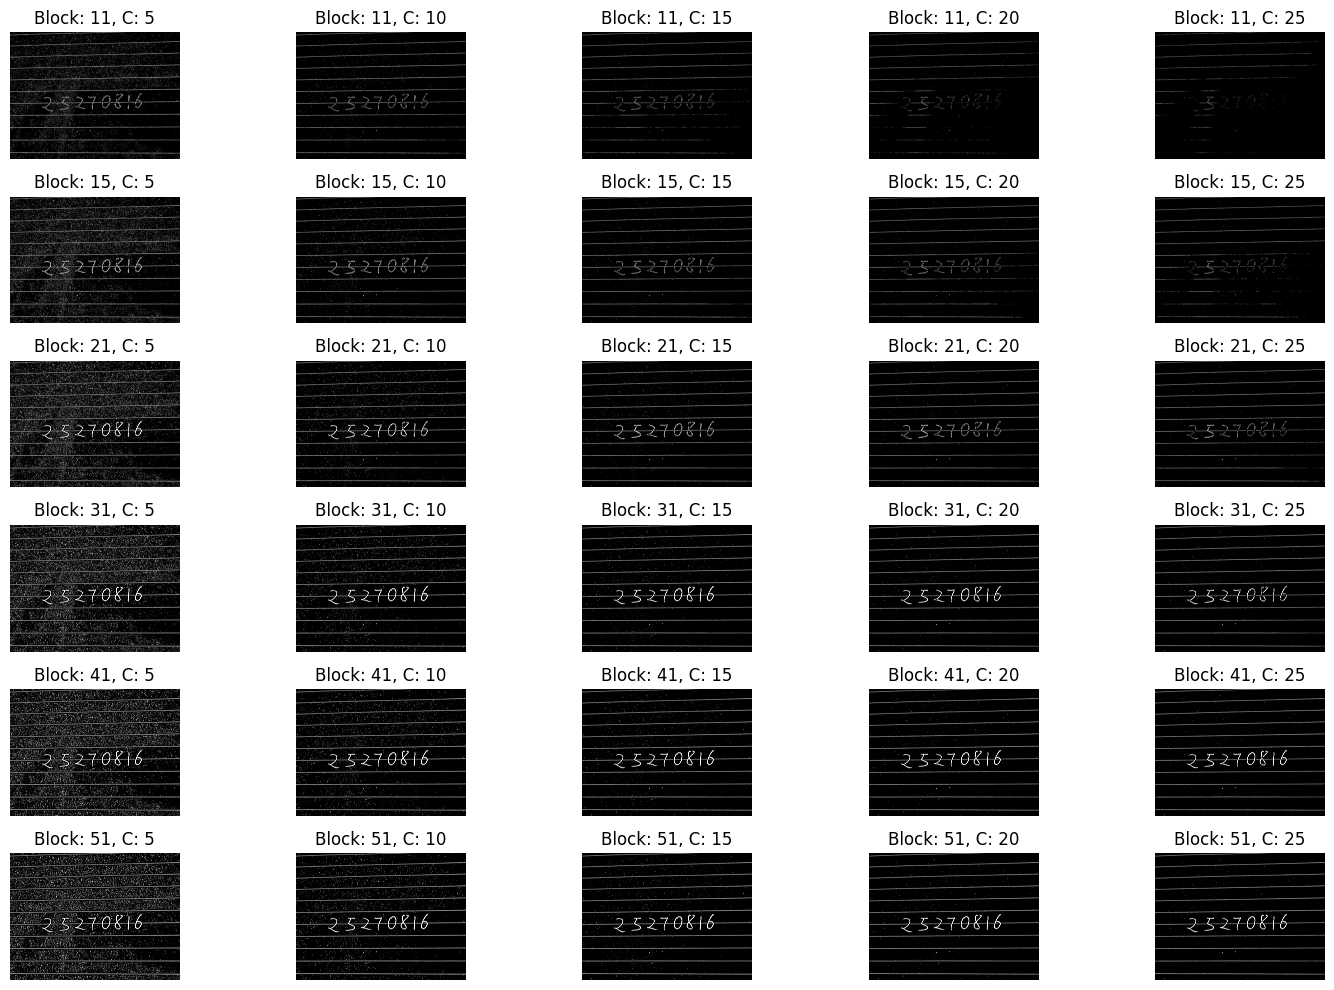

In [ ]:
# Tuning Adaptive Threshold Parameters
block_sizes = [11, 15, 21, 31, 41, 51]  # Test different block sizes
constants = [5, 10, 15, 20, 25]         # Test different constants

# Create a grid for visualizing results
plt.figure(figsize=(15, 10))
idx = 1
for block_size in block_sizes:
    for c in constants:
        # Apply adaptive threshold
        thresholded = cv2.adaptiveThreshold(
            blurred_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, c
        )
        # Display the result
        plt.subplot(len(block_sizes), len(constants), idx)
        plt.imshow(thresholded, cmap='gray')
        plt.title(f"Block: {block_size}, C: {c}")
        plt.axis('off')
        idx += 1

plt.tight_layout()
plt.show()

From all the parameter combinations tried, we can see that the max constant of 25, seems to work well with other block sizes. From block size 31 and above we start to see a better binary image with less noise.

Although, block size of 31 and 15> gives good binary images, 51 and 25 seems to be the best result. Lets now test this on other images before moving to the other preprocessing steps.

In [ ]:
unprocessed_image_indexes = [0,2,5,6,11]
for i in unprocessed_image_indexes:
  gray_check_img = cv2.cvtColor(real_world[i], cv2.COLOR_RGB2GRAY)
  thresh_check = cv2.adaptiveThreshold(gray_check_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY_INV, 51, 25)
  check_img_blurred = cv2.GaussianBlur(thresh_check,(5,5),0)
  cv2_imshow(check_img_blurred)

Output hidden; open in https://colab.research.google.com to view.

The adaptive threshold with ADAPTIVE_THRESH_MEAN_C and block size of 51 and constant of 25 works well for all images in our data set excluding the already processed images. Now we proceed.

In [147]:
# Applying the best block size and constant from the tuning above that effectively distinguishes the background from foreground u
thresh = cv2.adaptiveThreshold(blurred_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY_INV, 51, 25)
# cv2_imshow(resized_thresh)
thresh = cv2.GaussianBlur(thresh,(25,25),0)
# cv2_imshow(reduce_size(thresh))
cv2_imshow(thresh)

Output hidden; open in https://colab.research.google.com to view.

While thresholding helps to separate the objects from the background, it sometimes introduces or highlights some noise. For example some images have a white background with black or colored lines as design. These lines are introduces some noise after thresholding. Therefore, further steps have to be carried out to remove or reduce these noise.

We would be using 2 more steps to further reduce noise.

- Morphologyex: This operation has 2 basic operations `EROSION` and `DILATION`.
    * **Erosion** slides the kernels through the image and turns a pixel to one only when the pixels within the kernelk at the time is 1. It reduces the ther pixels near the boundary.

    * **Dilation** does the opposite of erosion by epsnding the white region when atleast 1 of the pixels in the kernel is 1.

To better harness the power of the 2 basic operationS we would be using a bit of both operations combined in `MORPH_OPEN`. This operation applies erosion to reduce the region and then apply dilation again. This helps us better highlight the area of interest.


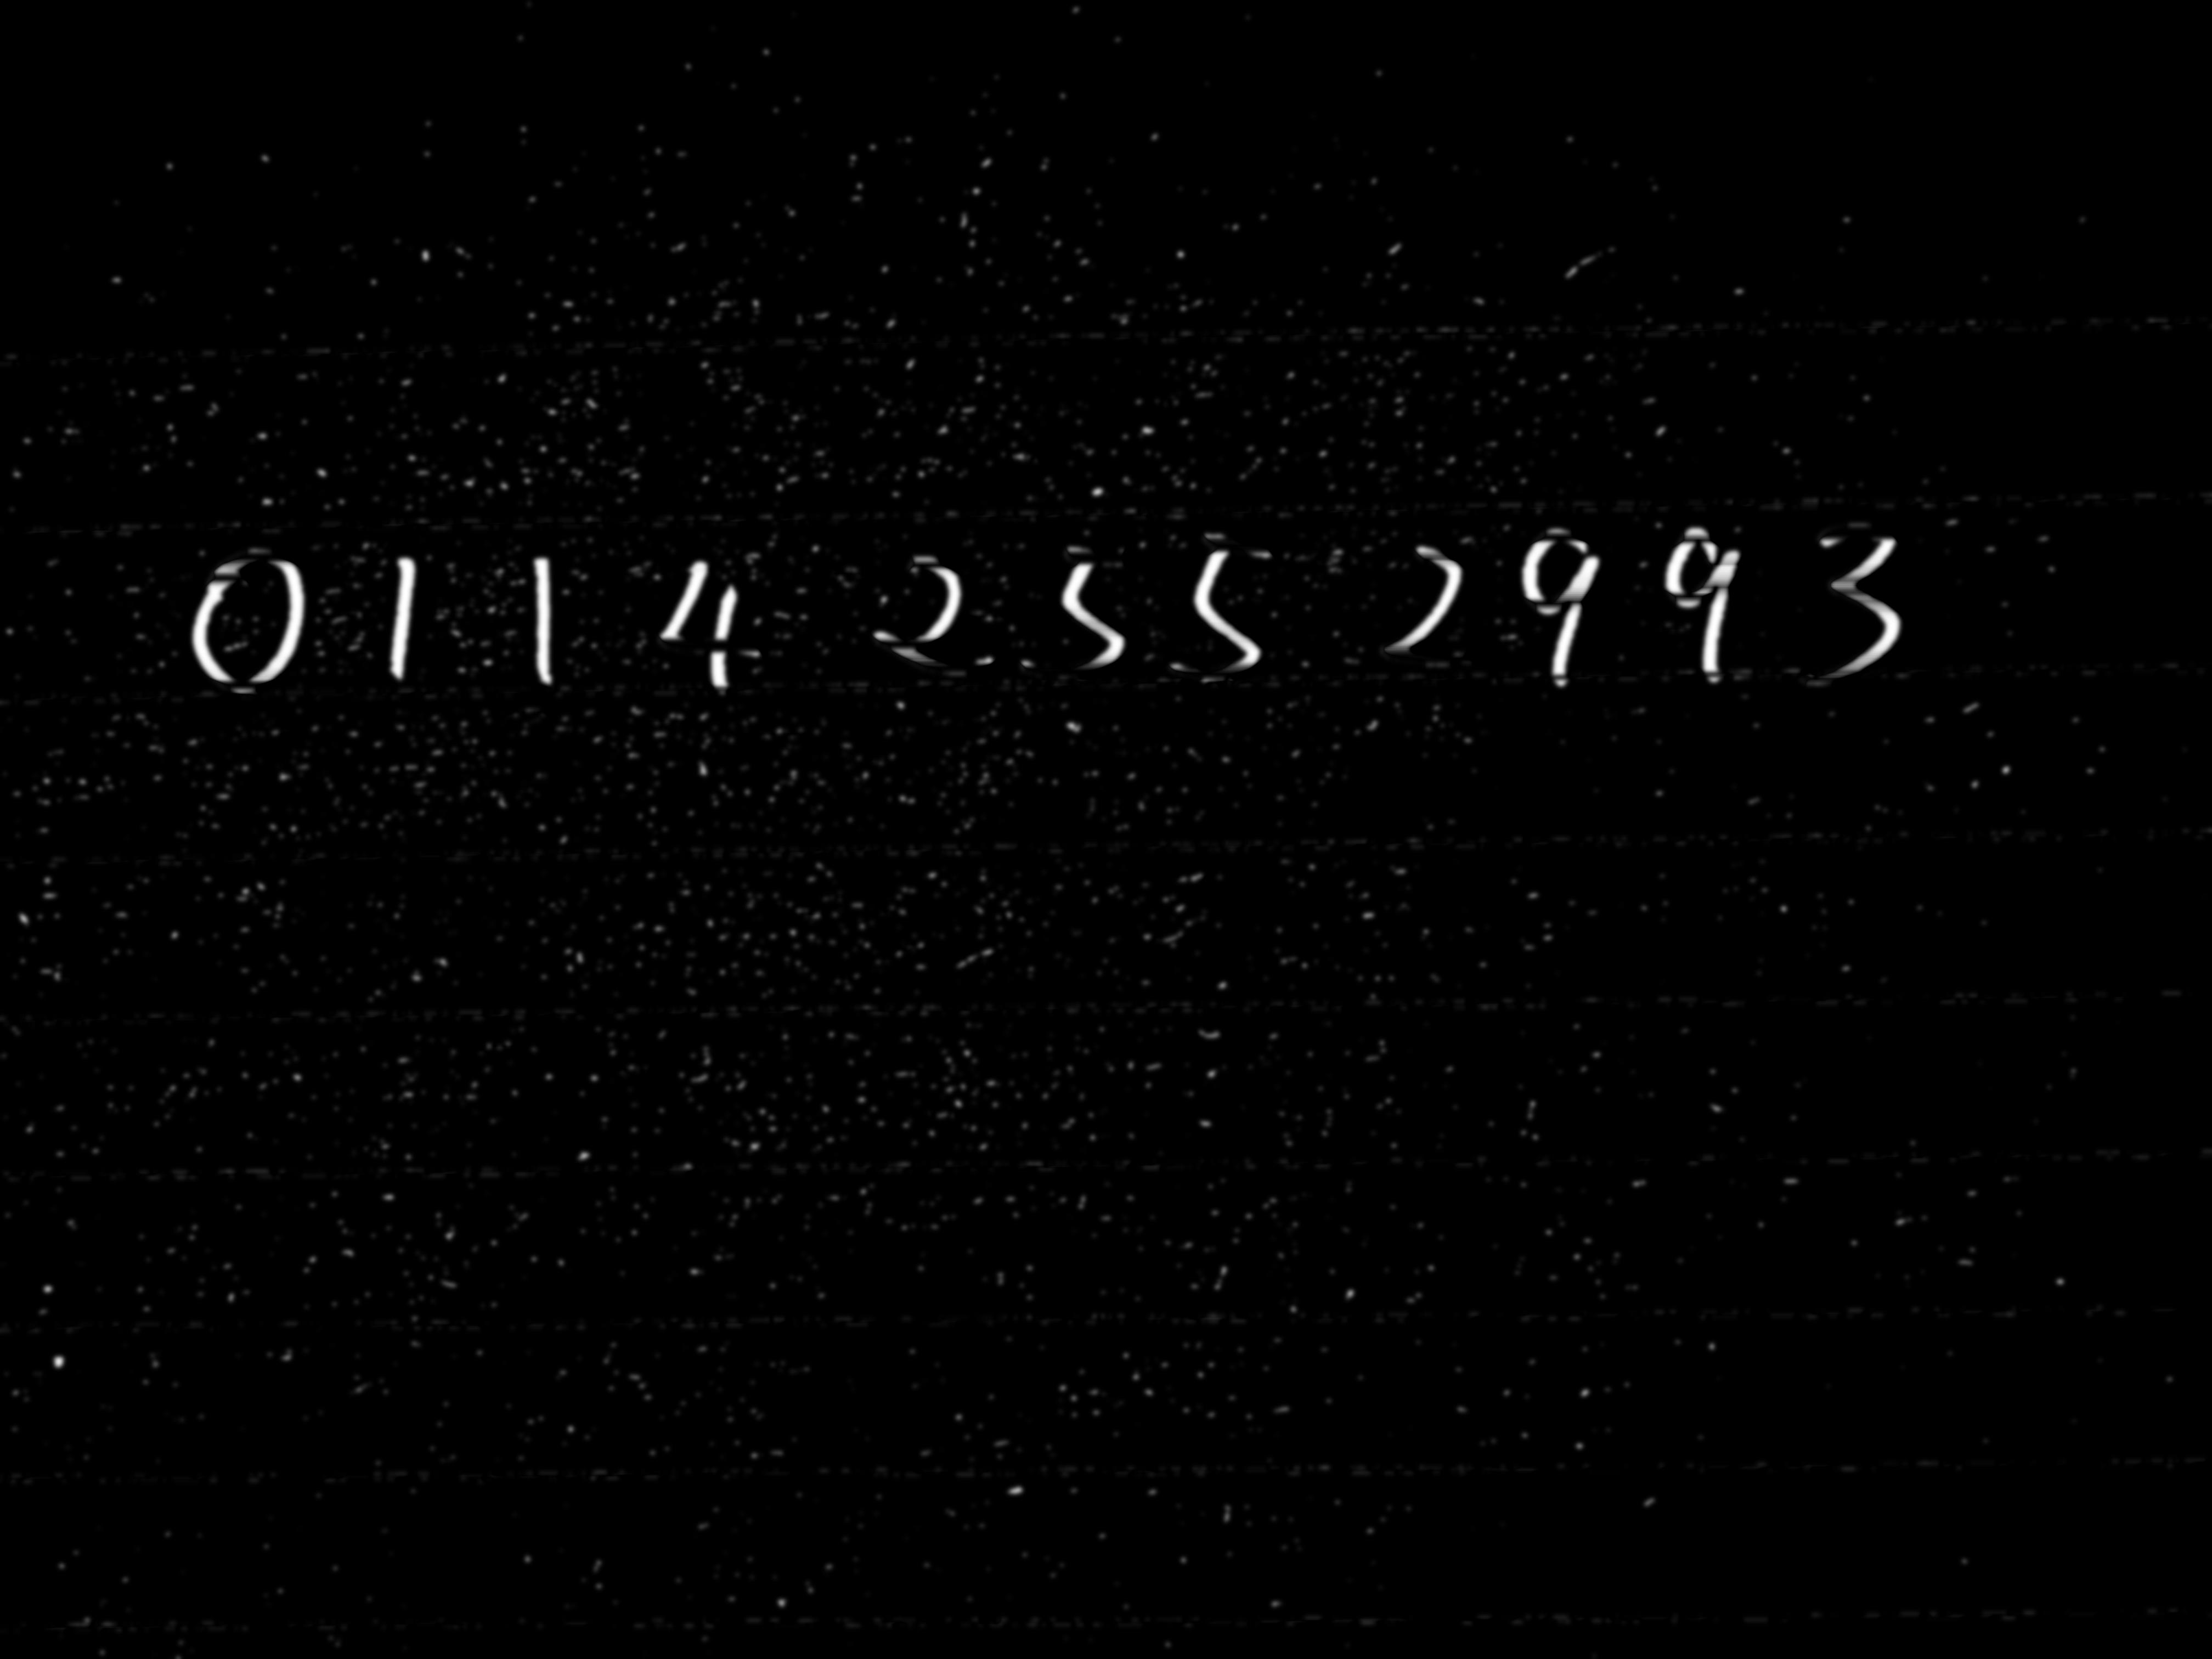

In [148]:
kernel = np.ones((1, 50), np.uint8)  # Kernel size (1, 50) for horizontal line detection
# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,50))
horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
processed_img = cv2.subtract(thresh, horizontal_lines)

cv2_imshow(processed_img)

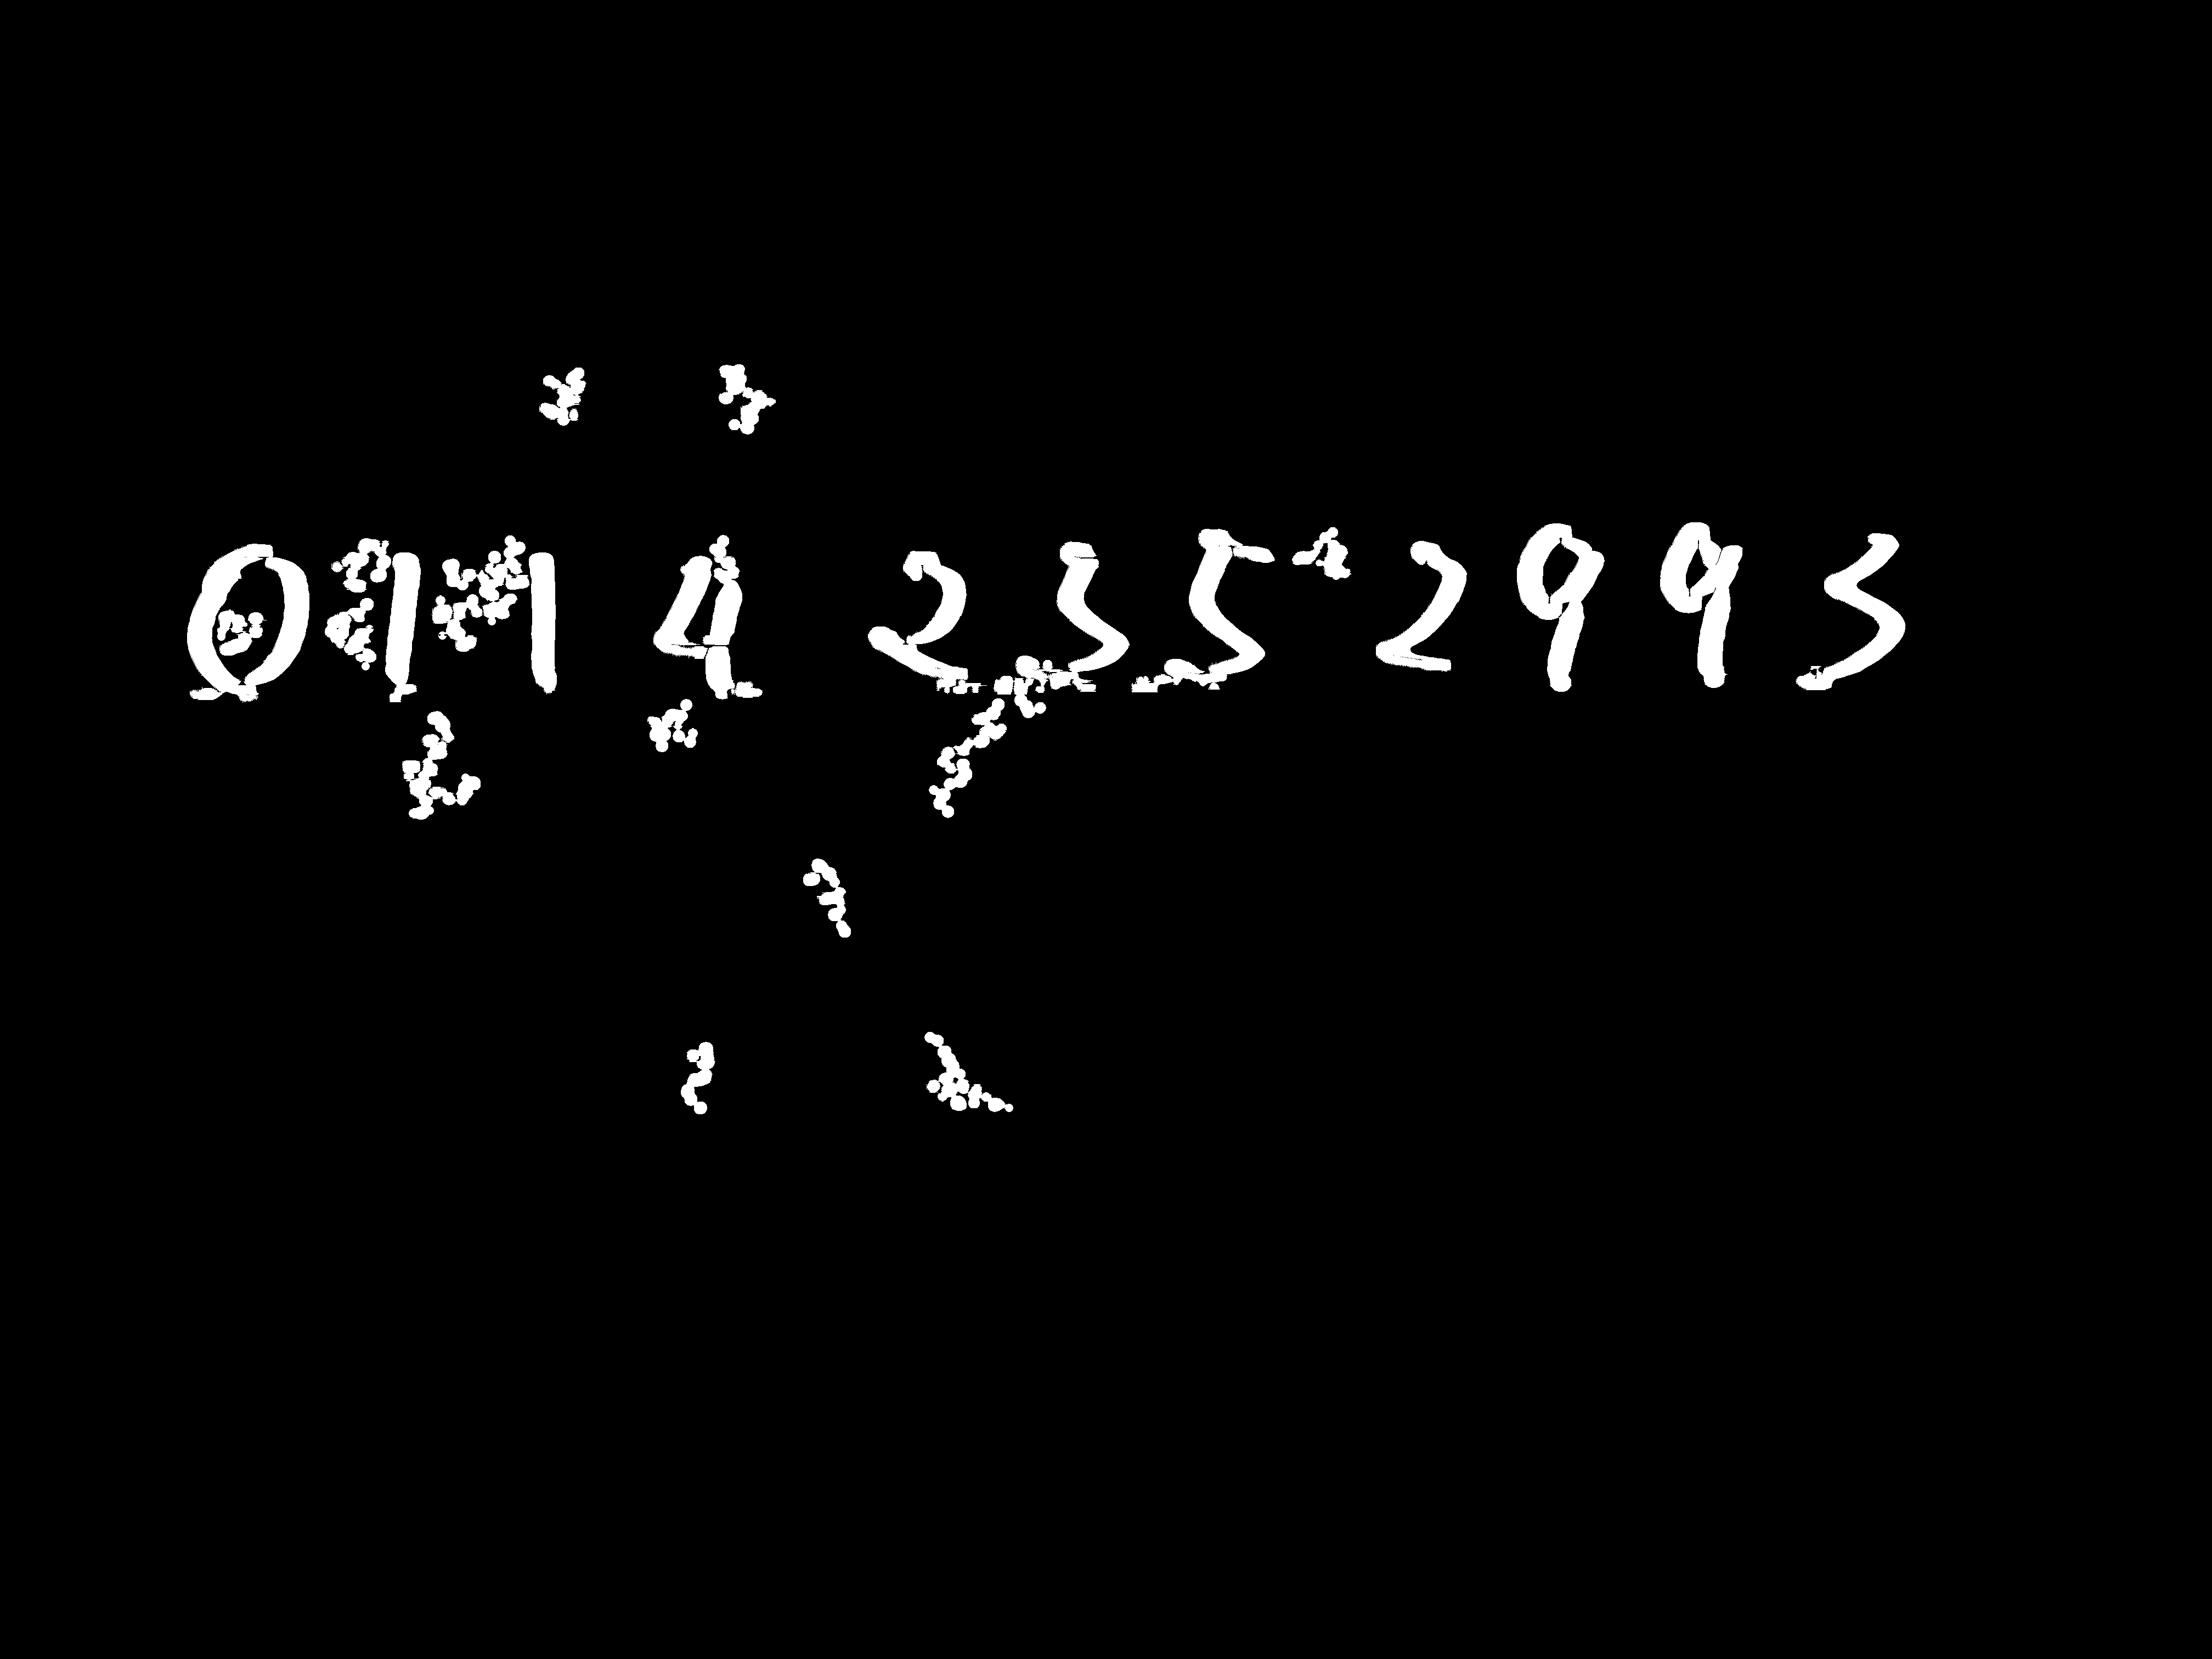

In [151]:
# Subtract the detected lines from the original image
processed_img = cv2.subtract(thresh, horizontal_lines)
processed_img = morphology.remove_small_objects(processed_img.astype(bool), min_size=4000) # adjust min_size as required.

# Convert back to uint8 for display (if needed)
processed_img = processed_img.astype(np.uint8) * 255

cv2_imshow(processed_img)

To remove the lines we need to specify the kernel size. In the code I commented out the `kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))` experiment
because, it removed the background line but also affected most of the digits making it hard to separate further noise from the digits. Because we are trying to remove the back ground lines which are hgorizontal, I created a kernel that forms a rectangular array `np.ones((1, 50), np.uint8)` which can cover the length of the horizontal lines.

After applying erosion and then dilation (MORPH_OPEN) we were able to remove the lines. While morphology works well for most images in our test set to remove most of the lines by subtracting them from the threshold binary image, we still have some noise in the image. To further remove them we use the morphology object called remove_small_objects. It removes white spots by checking if the connected pixels are below the set minimum size.

It is also observed that the minimum size differs from images to frames from a video (This experiement was done in other notebook used for experiment). This could be due to the lightning conditions because for images we can set the light condition when we capture the image but for videos it can differ from frame to frame.

This makes it difficult for us to use the same minimum size of connected pixels for images for frames from a video as seen above.

As a result, this step will be turned to a function to allow us set the minimum_size when preprocessing images or video frames.

In [152]:
def remove_background_noise(img, min_size):
  kernel = np.ones((1, 50), np.uint8)  # Kernel size (1, 50) for horizontal line detection
  horizontal_lines = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=1)

  # Subtract the detected lines from the original image
  processed_img = cv2.subtract(img, horizontal_lines)
  cv2_imshow(processed_img)
  print('\n-------------------------Remove Smaller Noise----------------------')

  processed_img = morphology.remove_small_objects(processed_img.astype(bool), min_size=min_size)#min_size=min connected pixels

  # Convert back to uint8 for display (if needed)
  processed_img = processed_img.astype(np.uint8) * 255

  return processed_img

In [154]:
# Find contours
# contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# CHAIN_APPROX_SIMPLE retuns the end points of the lines forming the boxes rather than all points. it returns 4 points
# contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(processed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out small contours based on area
min_contour_area = 500  # Set appropriate threshold
filtered_contours = [c for c in contours if cv2.contourArea(c) > min_contour_area]

print(f"Number of filtered contours: {len(filtered_contours)}")

digit_seq_copy = digit_seq.copy()
# Draw bounding boxes around each detected contour (digit)
digit_bounding_boxes = []
cont_count = 0 # conturs areas
# for contour in contours:
for contour in filtered_contours:
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / float(h)
    # if aspect_ratio < 1.0 and w > 40 and h > 50:
    if aspect_ratio < 1.0 and w > 10 and h > 20:
      print(f'width: {w}, height: {h}, aspect_ratio: {aspect_ratio}')
    # if 0.2 < aspect_ratio < 1.5 and 70 < w < 265 and 100 < h < 322:  # Fine-tune thresholds
      cv2.rectangle(digit_seq_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
      cont_count+=1
      digit_bounding_boxes.append((x, y, w, h))
print(f"Number of contour area: {cont_count}")

# cv2_imshow(reduce_size(digit_seq_copy))  # Show the image with bounding boxes
cv2_imshow(digit_seq_copy)  # Show the image with bounding boxes

Output hidden; open in https://colab.research.google.com to view.

After thresholding and handling noise, it is evident that there are some noise left in the image. Next we try to identify the objects in the image by detecting the conturs and drawing a bounding box over the area.

To get the conturs, we use `findContours` from open cv to detect boundaries. We specify the `RETR_EXTERNAL` retrieval mode to ensure we only only detect outtermost conturs. Coupled with the `CHAIN_APPROX_SIMPLE` to give us the end point of the lines to be used to draw the boxes rather than all the points around the contur.


## **Contur Filtering**

The purpose of detecting the conturs is to identify object in the image. From the detected conturs we can filter out noise by setting the minimum required contur area which we have set to 500. i.e Any area that is less than the specified area is ignored.

We then iterate through all the conturs that are above the threshold to draw the bounding boxes on the original image. Although the minimum area removed many noise, some noise managed to escape this because they have areas that are close to that of the written digits. To remove them, we try to filter by the aspect ratio, height and width of each box. Because I intend to make this a robust system that can handle different kinds of images, we have to give room for error so that the thresholds do not affect the written digits in some images.

## **6.3 Predicting from the boxes**

Since the boxes are successfully drawn around the digits, we try to make predictions based on the digits in each box. By using the bounding boxes to crop the preprocessed image and feding it to the model.

In [155]:
digit_bounding_boxes.sort(key=lambda box: box[0])
model.eval()

# Extract and resize digits
digit_images = []
for (x, y, w, h) in digit_bounding_boxes:
    digit_crop = processed_img[y:y+h, x:x+w]
    digit_resized = cv2.resize(digit_crop, (28, 28))
    digit_images.append(digit_resized)


for i in range(len(digit_images)):
  print('')
  cv2_imshow(digit_images[i])
  image = digit_images[i]
  # Pass the image through the model (no gradients needed for inference)
  with torch.no_grad():  # This prevents unnecessary calculations for gradients
      output = model(preprocess_image(image))

  # Get the predicted class (index of the highest probability)
  _, predicted_class = torch.max(output, 1)

  # Print the prediction
  print(f"Predicted Class: {predicted_class.item()}")


###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 3



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 5



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 0



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 6



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 4



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 0



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 4



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 0



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 3



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 7



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 5



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 5



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 2



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 7



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 7



###################################### PREPROCESSING IMAGE #######################################
Predicted Class: 5


While the model was able to preprocess some of the digits it still had some errors. This suggests that some improvements to the preprocessing steps is required.


Next we put all the above together to easily preprocess images with digit sequence.

In [53]:
def preprocess_digit_sequence_image(image, mnist_image=False, min_size=4000):
  print('###################################### PREPROCESSING IMAGE #######################################')
  gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  blurred_img = cv2.GaussianBlur(gray_img,(5,5),0)

  print('\n---------------------Remove BackGround Noise----------------------')
  thresh = cv2.adaptiveThreshold(blurred_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,

                                          cv2.THRESH_BINARY_INV, 51, 25)
  thresh = cv2.GaussianBlur(thresh,(25,25),0)
  cv2_imshow(reduce_size(thresh))

  print('\n----------------------Further Noise Removal-----------------------')
  processed_img = remove_background_noise(thresh, min_size)
  cv2_imshow(processed_img)

  # Find contours
  contours, _ = cv2.findContours(processed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # Filter out small contours based on area
  min_contour_area = 500  # Set appropriate threshold
  filtered_contours = [c for c in contours if cv2.contourArea(c) > min_contour_area]

  print(f"\nNumber of filtered contours: {len(filtered_contours)}")

  # Draw bounding boxes around each detected contour (digit)
  digit_bounding_boxes = []
  cont_count = 0 # conturs areas

  for contour in filtered_contours:
      x, y, w, h = cv2.boundingRect(contour)
      aspect_ratio = w / float(h)
      if 0.4 < aspect_ratio < 1.0 and w > 40 and h > 50:
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cont_count+=1
        digit_bounding_boxes.append((x, y, w, h))
  print(f"Numbers detected: {cont_count}")

  cv2_imshow(reduce_size(image))  # Show the image with bounding boxes

  # The bounding boxes may not be well ordered due to the conturs so we have to sort by x-coordinate --> left to right
  digit_bounding_boxes.sort(key=lambda box: box[0])

  # Extract and resize digits
  digit_images = []
  for (x, y, w, h) in digit_bounding_boxes:
      # digit_crop = thresh[y:y+h, x:x+w]
      digit_crop = processed_img[y:y+h, x:x+w]
      digit_resized = cv2.resize(digit_crop, (28, 28))
      digit_images.append(digit_resized)
      cv2_imshow(digit_resized)

  # Normalize and convert to tensor
  transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
  digit_tensors = [transform(digit) for digit in digit_images]

  return digit_tensors, digit_images

**Images with black background**

In [94]:
real_world = load_data()

Loading Images...
successfully loaded images: 15 images.


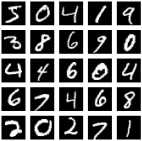

In [95]:
black_background_image = real_world[2]
cv2_imshow(reduce_size(black_background_image))

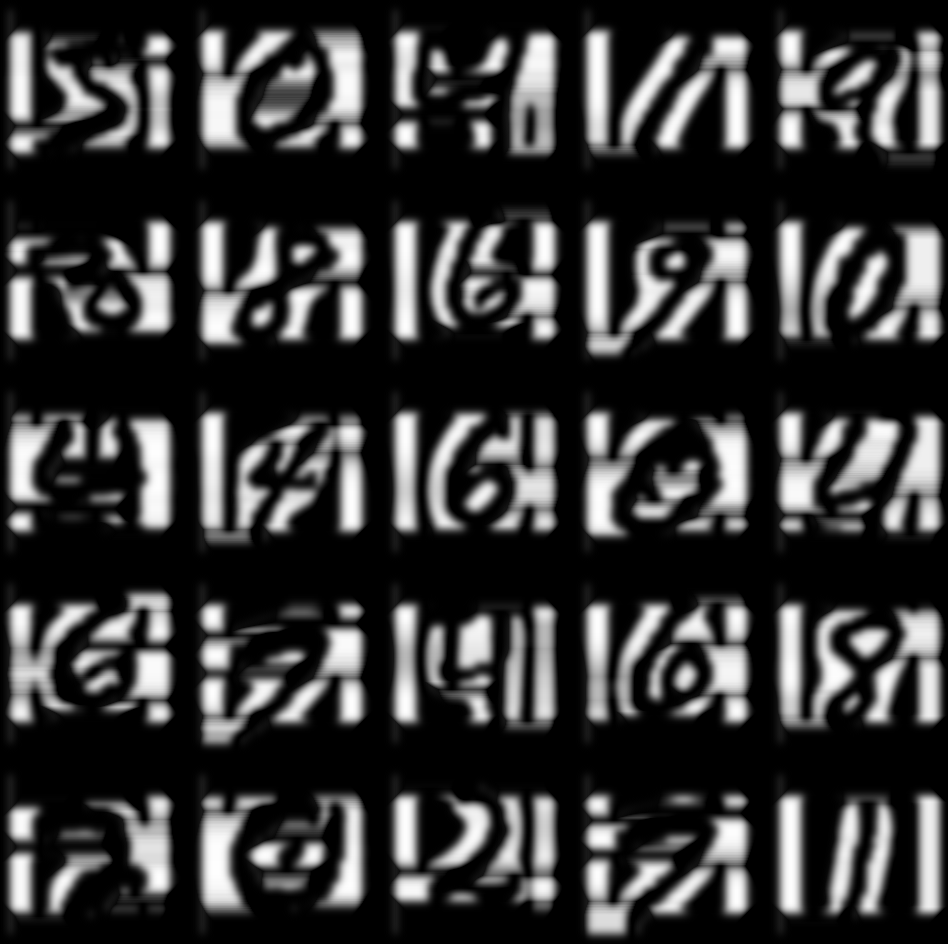


-------------------------Remove Smaller Noise----------------------


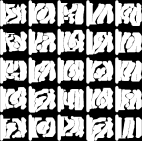

In [86]:
gray_img_black = cv2.cvtColor(black_background_image, cv2.COLOR_RGB2GRAY)
blurred_img_black = cv2.GaussianBlur(gray_img_black,(5,5),0)

thresh_black = cv2.adaptiveThreshold(blurred_img_black, 255, cv2.ADAPTIVE_THRESH_MEAN_C,

                                        cv2.THRESH_BINARY_INV, 51, 25)
thresh_black = cv2.GaussianBlur(thresh_black,(25,25),0)

processed_img_black = remove_background_noise(thresh_black, min_size = 40)
cv2_imshow(reduce_size(processed_img_black))

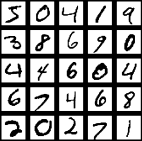

In [96]:
_, processed_img_black = cv2.threshold(blurred_img_black, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
cv2_imshow(reduce_size(processed_img_black))

Applying the adaptive threshold and parameters that worked for white background images doesnt seem to work well with blackbackground images.

In [70]:
def preprocess_image_with_balck_background(image, mnist_image=False):
  print('###################################### PREPROCESSING IMAGE #######################################')

  gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  blurred_img = cv2.GaussianBlur(gray_img,(5,5),0)

  print('\n---------------------Remove BackGround Noise----------------------')
  _, processed_img = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
  cv2_imshow(processed_img)

  # Find contours
  contours, _ = cv2.findContours(processed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # Filter out small contours based on area
  min_contour_area = 500  # Set appropriate threshold
  filtered_contours = [c for c in contours if cv2.contourArea(c) > min_contour_area]

  print(f"\nNumber of filtered contours: {len(filtered_contours)}")

  # Draw bounding boxes around each detected contour (digit)
  digit_bounding_boxes = []
  cont_count = 0 # conturs areas

  for contour in filtered_contours:
      x, y, w, h = cv2.boundingRect(contour)
      aspect_ratio = w / float(h)
      cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
      cont_count+=1
      digit_bounding_boxes.append((x, y, w, h))
  print(f"Numbers detected: {cont_count}")

  cv2_imshow(reduce_size(image))  # Show the image with bounding boxes

  # The bounding boxes may not be well ordered due to the conturs so we have to sort by x-coordinate --> left to right
  digit_bounding_boxes.sort(key=lambda box: box[0])

  # Extract and resize digits
  digit_images = []
  for (x, y, w, h) in digit_bounding_boxes:
      # digit_crop = thresh[y:y+h, x:x+w]
      digit_crop = gray_img[y:y+h, x:x+w]
      digit_resized = cv2.resize(digit_crop, (28, 28))
      digit_images.append(digit_resized)
      cv2_imshow(digit_resized)

  # Normalize and convert to tensor
  transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
  digit_tensors = [transform(digit) for digit in digit_images]

  return digit_tensors, digit_images

The `preprocess_image_with_balck_background` and `preprocess_digit_sequence_image` functions are a combination of the results of the experiment carried out in the previous cells.

**preprocess_digit_sequence_image:** This function handles images with white background. It gets the threshold using adaptivethreshold, remove noise, detect conturs and draw bounding boxes around the detected digits.

**preprocess_image_with_balck_background:** This function is a modification of the `preprocess_digit_sequence_image` function. The only difference is that is works with imges that have blackbackground. Since these images already have a black background we preset a threshold value.

**6.4 Video Preprocessing**

In [36]:
# Function to calculate similarity
def is_similar(frame1, frame2, threshold=0.9):
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    score, _ = ssim(gray1, gray2, full=True)
    return score >= threshold

In [37]:
def preprocess_video(video_path):
  cap = cv2.VideoCapture(video_path)

  frame_count = 0
  similarity_threshold = 0.9  # Similarity score threshold
  consecutive_frames = 3  # Number of consecutive frames to check similarity
  frame_buffer = []  # Buffer to store frames for comparison
  selected_frames = []
  selected_frames_count = 0

  print('********************************* EXTRACTING STABLE FRAMES **************************************')

  while cap.isOpened():
      success, frame = cap.read()
      if not success: # check if a frame was returned
          break
      # cv2_imshow(frame)
      frame_count += 1

      frame_buffer.append(frame) # Add frame to frame_buffer list

      # Check if buffer has enough frames
      if len(frame_buffer) >= consecutive_frames:
          stable = True

          # Compare all frames to the first frame in the buffer
          for i in range(1, len(frame_buffer)):
              if not is_similar(frame_buffer[0], frame_buffer[i], threshold=similarity_threshold):
                  stable = False
                  break

          if stable: # If the frames in the buffer are similar select it
              print(f"\nFrame {frame_count} is stable.")
              selected_frames.append(frame_buffer[-1])
              selected_frames_count+=1

          frame_buffer.clear()  # Clear the buffer for the next set of frames
  print(f"\nTotal frames in the video: {frame_count}")
  print(f'Selected Frames: {selected_frames_count}')

  cap.release()

  return selected_frames

The `preprocess_video` function is designed to extract stable frames from a video file.
It identifies and select frames that have little changes compared to their preceding frames. We do this as this is a more effiecint way rather than extracting all frames and preprocessing each frame. With this approcah we can focus on a few relevant frames.

**Process:**
First the function opens the video and then we define some variables that will enable us get the best frames from the video.

The cap.read returns a boolean value that taells us if a frame was detected and then it returns the frame. If it does not return a frame, it breaks out of the loop.

If a frame is found, it is added to a list that serves as a temporary holder for 3 frames at a time. The frames in the buffer are then compared using the `is_similar` function to check if the frames in the buffer are the same. If they are the same, we only save one frame. At the end of these iterations we would have gotten a reduced number of frames that would most likely include a frame that captures all the written digits. These frames can then be passed to the video frames preprocessing functions to detect and predict the digit written.

********************************* EXTRACTING STABLE FRAMES **************************************

Frame 75 is stable.

Frame 84 is stable.

Frame 93 is stable.

Frame 117 is stable.

Frame 120 is stable.

Frame 183 is stable.

Frame 252 is stable.

Total frames in the video: 260
Selected Frames: 7


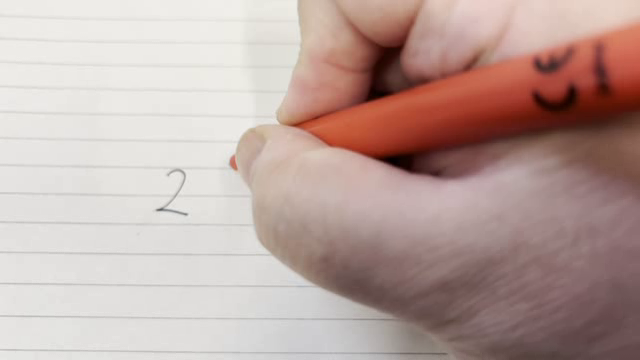

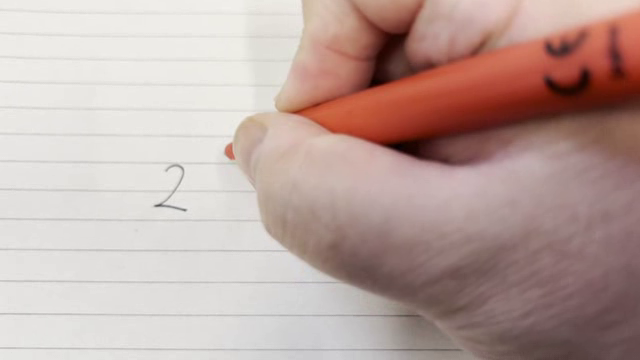

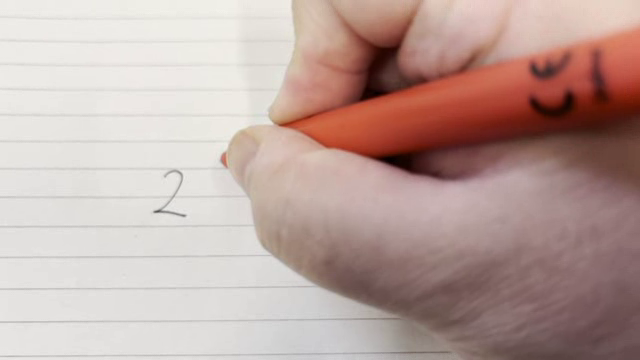

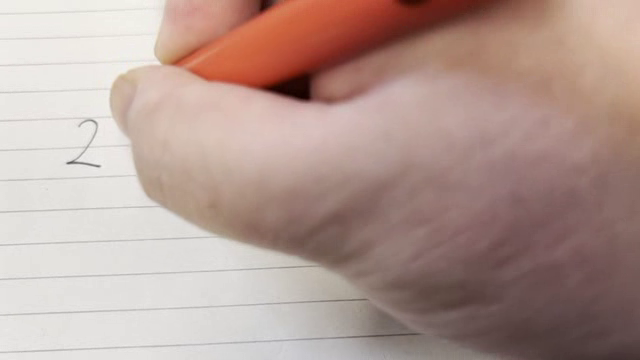

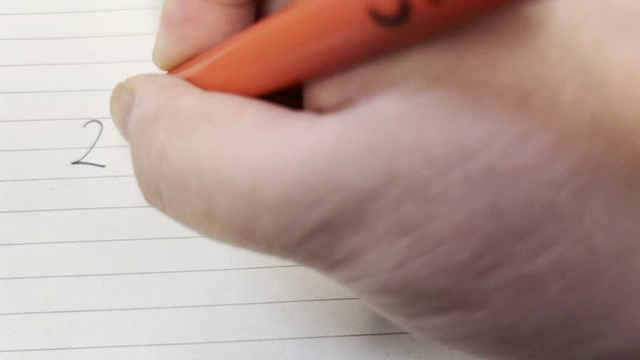

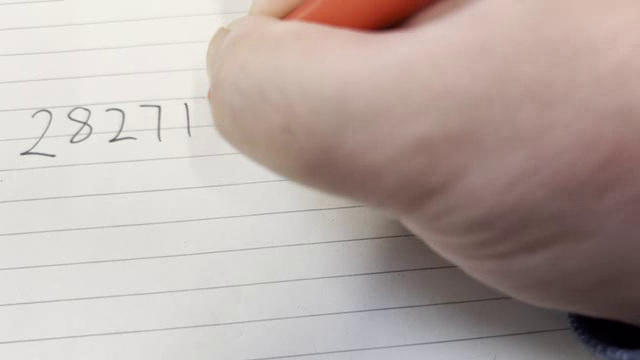

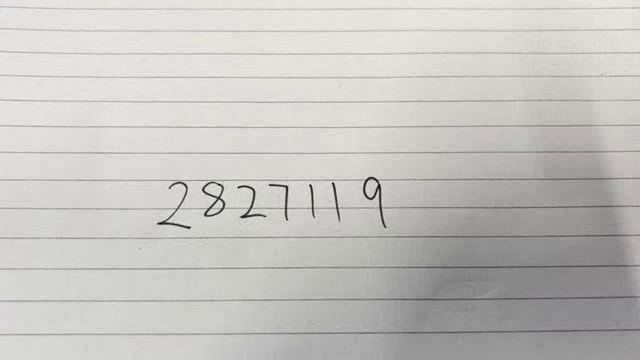

In [8]:
# testing the Video capture function
video_path = "/content/drive/MyDrive/Module projects/ML&_Computer_Vision/Number_Test_Data/015.avi"
frames = preprocess_video(video_path)
for frame in frames:
  cv2_imshow(frame)

Testing the finction on the test video data, we see that it returns 7 frames from a total of 260 video frames. Although in this case, only the last frame shows the complete numbers it is still does the job.

### **7. <font color='red'>  Prediction Pipeline** </font>

In the steps above, we have defined different preprocessing steps to handle different types of data, from already preprocessed data (MNIST samples) to real world images and videos of hand written digits. Now we have to put all of this together  to form a robust pipeline that can be used to preprocess and predict the digits found or written.

In [38]:
def is_image_or_video(data):
    """Checks if the data is an image or video based on its type and shape.

    Args:
        data: The input data (file path, NumPy array, etc.).

    Returns:
        "image", "video", or None if the format is not recognized.
    """
    if isinstance(data, str):  # If it's a file path, check extension
        ext = os.path.splitext(data)[1].lower()
        if ext in ['.jpg', '.jpeg', '.png', '.gif', '.bmp']:
            return "image"
        elif ext in ['.mp4', '.avi', '.mov', '.mkv', '.wmv']:
            return "video"
        else:
            return None
    elif isinstance(data, np.ndarray):  # check if it's a NumPy array (likely an image)
        if data.ndim == 2 or (data.ndim == 3 and data.shape[2] in [3, 4]): # 2D OR 3D images with 3/4 color channels
            return "image"
        else:
            return None  # Handle other array shapes as needed
    else:
        return None  # Handle unsupported data types if needed

In [75]:
def data_pipeline(image, mnist=False):
  """Processes an image or video for digit recognition using a trained CNN model.

  This function serves as the main pipeline for digit recognition. It takes an image
  or a video as input and performs the necessary preprocessing steps before
  feeding the data to the trained CNN model for prediction. It handles different
  input types (MNIST images, real-world images, and videos) and applies appropriate
  preprocessing techniques based on the input type.

  Args:
    image: The input image (NumPy array) or video path (string).
    mnist: A boolean indicating whether the input is an MNIST image.
            Defaults to False.

  Returns:
    None. It prints the predicted digit(s).

  Process:
    1. MNIST Image Handling: If `mnist` is True, it assumes the input is an MNIST image and
        applies the `preprocess_image` function to prepare it for the model. Then, it makes
        a prediction using the model and prints the result.
    2. Video Handling: If the input is a video, it first extracts stable frames using
        the `preprocess_video` function. For each stable frame, it applies the
        `preprocess_digit_sequence_image` function to extract and preprocess digits,
        and then uses the `make_predict` function to predict and print the digits.
    3. Real-world Image Handling: If the input is a real-world image, it first determines
        the background color (black or white). Based on the background color, it applies
        either `preprocess_image_with_balck_background` or `preprocess_digit_sequence_image`
        to preprocess the image. Finally, it uses the `make_predict` function to predict
        and print the digits.
  """

  ############################################## MNIST #####################################################
  if mnist:
    processed_digit = preprocess_image(image)
    with torch.no_grad():  # This prevents unnecessary calculations for gradients
      output = model(processed_digit)

    predicted_class = torch.argmax(output, 1)
    print(f"Predicted Class: {predicted_class.item()}")

  ############################################## REAL WORLD VIDEO ################################################
  if is_image_or_video(image) == 'video' and not mnist:
    frames = preprocess_video(video_path)
    for frame in frames:
      image_tensors, detected_number = preprocess_digit_sequence_image(frame, min_size=50)
      make_predict(model, image_tensors)

  ############################################## REAL WORLD IMAGES ################################################
  if is_image_or_video(image) == 'image' and not mnist:
    if detect_background(image) == 'black': # if image has a black background
      image_tensors, detected_number = preprocess_image_with_balck_background(image)
      make_predict(model, image_tensors)

    else:
      image_tensors, detected_number = preprocess_digit_sequence_image(image)
      make_predict(model, image_tensors)


In [40]:
def make_predict(model, image_tensors):
  predicted_classes = []
  number_string = ""

  for digit_tensor in image_tensors: # Use image_tensors directly
    digit = digit_tensor.unsqueeze(0)

    with torch.no_grad():  # This prevents unnecessary calculations for gradients
        output = model(digit)

    # Get the predicted class (index of the highest probability)
    predicted_class = torch.argmax(output, 1)
    predicted_classes.append(predicted_class.item())

  number_string = "".join(str(num) for num in predicted_classes)
  # cv2_imshow(reduce_size(image))
  if number_string:
    print(f"Predicted Number: {number_string}")

Having experimented with different parameters, preproessing steps and techniques to handle different kinds of noise that could be present in an image, we were able to fine and tune some steps to suit different scenarios.

To make a robust pipeline that can hanlde images and videos we have combined all the steps taken earlier into 1 called `data_pipeline`.

This function only takes in 2 arguments `image` and `mnist`.  The `mnist` parameter checks if the passed image is an already preprocessed image that does not require any preprocessing.

If `mnist` parameter is false, it applies the `is_image_or_video` to check if it is a video or an image which has not been already preprocessed, it applies the `preprocess_digit_sequence_image` function to get the cropped digits and make predictions with the `make_predict` function.

Loading Images...
successfully loaded images: 15 images.
###################################### PREPROCESSING IMAGE #######################################

---------------------Remove BackGround Noise----------------------


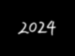


----------------------Further Noise Removal-----------------------


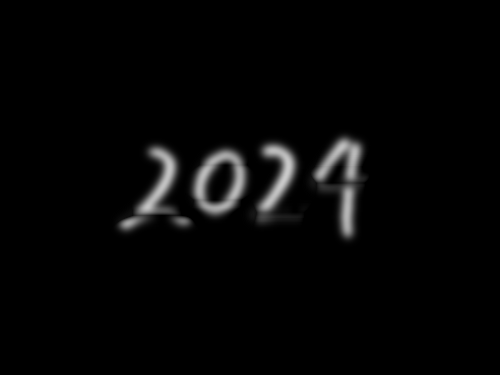


-------------------------Remove Smaller Noise----------------------


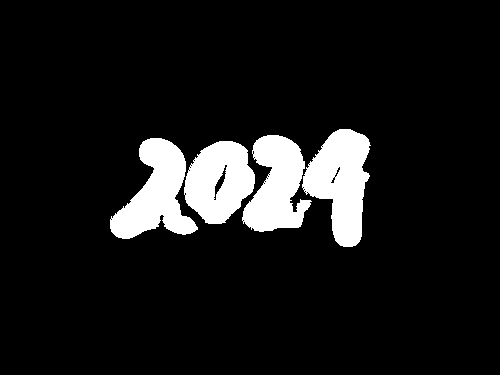


Number of filtered contours: 4
Numbers detected: 4


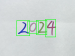

Predicted Number: 2024


In [24]:
real_world = load_data()
data_pipeline(real_world[5], mnist=False)

### The End 😁

---